## Image Diff

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # note: also set this in the shell before launching jupyter
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from standard_e2e import Modality

TRAIN_DIR     = '../data/processed/waymo_e2e/training/'
MANIFEST_PATH = '../data/train_manifest.json'
FEATURES_DIR  = '../data/processed/waymo_e2e/features/'

CLASSES = ['straight', 'left-turn', 'right-turn', 'lane-change-left', 'lane-change-right']

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)
print(f'{len(manifest)} sequences in manifest')

2037 sequences in manifest


In [2]:
# --- Confirm context-frame ordering: is the target the LAST element of context_fnames? ---
e = next(iter(manifest.values()))
print('target_fname:', e['target_fname'])
print('context last:', e['context_fnames'][-1], '(should == target)')
print('context prev:', e['context_fnames'][-2] if e['n_context'] > 1 else 'NONE')
assert e['context_fnames'][-1] == e['target_fname'], \
    'Expected target to be the last context frame; adjust prior-frame indexing below.'
print('\nConfirmed: prior frame = context_fnames[-2]')

target_fname: 003b62820d0e9345eb025de35b046999_10.npz
context last: 003b62820d0e9345eb025de35b046999_10.npz (should == target)
context prev: 003b62820d0e9345eb025de35b046999_9.npz

Confirmed: prior frame = context_fnames[-2]


## Per-frame functions (redefined for a self-contained notebook)

Copied from `waymo_feature_extraction.ipynb`. Keep in sync until factored into a shared module.

In [3]:
# Exact copies of the v1 functions from feature_exploration_update.ipynb (cell 3).
# Keep in sync with that notebook until factored into a shared module.

def detect_edges_and_lines(img, canny_low=30, canny_high=100, hough_threshold=15,
                            min_line_length=20, max_line_gap=15, road_region_frac=0.55):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    H, W = gray.shape
    road_mask = np.zeros_like(gray); road_mask[int(H * road_region_frac):, :] = 1
    edges = cv2.Canny(gray, canny_low, canny_high)
    edges_masked = edges * road_mask
    lines_raw = cv2.HoughLinesP(edges_masked, rho=1, theta=np.pi / 180, threshold=hough_threshold,
                                 minLineLength=min_line_length, maxLineGap=max_line_gap)
    lines = []
    if lines_raw is not None:
        for line in lines_raw:
            x1, y1, x2, y2 = line[0]
            angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1)))
            if 20 < angle < 75 or 105 < angle < 160:
                lines.append((x1, y1, x2, y2))
    return edges, np.array(lines)


def estimate_vanishing_point(lines, img_shape):
    H, W = img_shape[:2]
    def line_intersection(l1, l2):
        x1, y1, x2, y2 = l1; x3, y3, x4, y4 = l2
        denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
        if abs(denom) < 1e-6: return None
        t = ((x1 - x3) * (y3 - y4) - (y1 - y3) * (x3 - x4)) / denom
        return (x1 + t * (x2 - x1), y1 + t * (y2 - y1))
    if len(lines) < 2: return (0.5, 0.5), len(lines)
    pts = [p for i in range(len(lines)) for j in range(i + 1, len(lines))
           if (p := line_intersection(lines[i], lines[j])) and -W < p[0] < 2 * W and -H < p[1] < 2 * H]
    if not pts: return (0.5, 0.5), len(lines)
    xs, ys = np.array([p[0] for p in pts]), np.array([p[1] for p in pts])
    hist, xe, ye = np.histogram2d(xs, ys, bins=[np.linspace(-W, 2*W, 30), np.linspace(-H, 2*H, 30)])
    pi = np.unravel_index(hist.argmax(), hist.shape)
    return (((xe[pi[0]] + xe[pi[0]+1]) / 2) / W, ((ye[pi[1]] + ye[pi[1]+1]) / 2) / H), len(lines)

In [4]:
# Exact copies of the v1 road functions from feature_exploration_update.ipynb (cell 3).

def get_robust_seed_color(hsv, H, W):
    pts = [(W//2, int(H*.95)), (W//2, int(H*.85)), (int(W*.35), int(H*.92)),
           (int(W*.65), int(H*.92)), (int(W*.35), int(H*.82)), (int(W*.65), int(H*.82))]
    colors, valid = [], []
    for sx, sy in pts:
        patch = hsv[max(0, sy-5):sy+5, max(0, sx-10):sx+10]
        if patch.size > 0:
            colors.append(np.mean(patch, axis=(0, 1))); valid.append((sx, sy))
    colors = np.array(colors)
    med = np.median(colors, axis=0)
    best = np.argmin(np.linalg.norm(colors - med, axis=1))
    return colors[best].astype(np.uint8), valid[best]


def segment_road(img, road_region_frac=0.55):
    H, W = img.shape[:2]
    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    seed_color, (sx, sy) = get_robust_seed_color(hsv, H, W)
    tol = np.array([20, 60, 60])
    mask = cv2.inRange(hsv, np.clip(seed_color.astype(int)-tol, 0, 255).astype(np.uint8),
                        np.clip(seed_color.astype(int)+tol, 0, 255).astype(np.uint8))
    mask[:int(H*road_region_frac), :] = 0
    flood = np.zeros((H+2, W+2), dtype=np.uint8)
    cv2.floodFill(mask.copy(), flood, (sx, sy), 255, loDiff=(10,10,10), upDiff=(10,10,10))
    road_mask = (flood[1:-1, 1:-1] * 255).astype(np.uint8)
    px = np.where(road_mask > 0)
    if len(px[0]) < 10:
        return road_mask, {'road_area_frac': 0., 'road_centroid_x': 0.5, 'road_taper': 0.}
    area = len(px[0]) / (H * W)
    cx = np.mean(px[1]) / W
    taper = (np.sum(road_mask[int(H*.9), :] > 0) - np.sum(road_mask[int(H*.7), :] > 0)) / W
    return road_mask, {'road_area_frac': area, 'road_centroid_x': cx, 'road_taper': taper}

 **Note:** the road/VP functions above are exact copies of the v1 functions from
`feature_exploration_update.ipynb` (cell 3), so `road_centroid_x`, `road_area_frac`, and
`vp_x` match the convention used by the committed `road.npy`. We use v1 (not v2) so the
difference feature is consistent with the existing baseline. Keep in sync until factored
into a shared module.

In [5]:
from ultralytics import YOLO
yolo_model = YOLO('yolov8s.pt')

DRIVING_CLASSES = {0, 1, 2, 3, 5, 7, 9, 11}  # person, bicycle, car, motorcycle, bus, truck, light, sign

def yolo_lateral_aggregates(img, model, driving_classes=DRIVING_CLASSES):
    """Aggregate lateral detection signal over ALL driving-relevant detections
    (not per-class), designed to be differenced between frames.

    Returns dict:
      det_mean_x     — mean normalized center-x over all detections (0.5 if none)
      det_lr_balance — (left_count - right_count) / total  (0.0 if none)
    """
    H, W = img.shape[:2]
    results = model(img, verbose=False)
    xs = []
    for box in results[0].boxes:
        if int(box.cls) in driving_classes:
            x1, _, x2, _ = box.xyxy[0].tolist()
            xs.append(((x1 + x2) / 2) / W)
    if not xs:
        return {'det_mean_x': 0.5, 'det_lr_balance': 0.0}
    xs = np.array(xs)
    left = (xs < 0.5).sum()
    right = (xs >= 0.5).sum()
    return {
        'det_mean_x': float(xs.mean()),
        'det_lr_balance': float((left - right) / len(xs)),
    }

In [6]:
# --- The 5 differenceable per-frame quantities ---
QUANTITY_KEYS = ['road_centroid_x', 'road_area_frac', 'vp_x', 'det_mean_x', 'det_lr_balance']

def compute_frame_quantities(img, model):
    """Compute the 5 scalar quantities for a single frame.
    Same function is reused across frames for the multi-frame (Stage 2) extension."""
    _, road = segment_road(img)
    _, lines = detect_edges_and_lines(img)
    (vp_x, _vp_y), _n = estimate_vanishing_point(lines, img.shape)
    det = yolo_lateral_aggregates(img, model)
    return {
        'road_centroid_x': road['road_centroid_x'],
        'road_area_frac':  road['road_area_frac'],
        'vp_x':            vp_x,
        'det_mean_x':      det['det_mean_x'],
        'det_lr_balance':  det['det_lr_balance'],
    }

def load_img(fname):
    data = np.load(os.path.join(TRAIN_DIR, fname), allow_pickle=True)
    return np.array(data['_modality_data'].item()[Modality.CAMERAS])

In [7]:
# --- Limit-1 difference extraction over all sequences ---
# feature = Q(target) - Q(prior),  prior = context_fnames[-2]
# Sequences with n_context==1 have no prior frame -> zero vector, valid=False.
import time

framediff = []
valid_mask = []
labels = []
seq_ids = []

start = time.time()
for i, (sid, entry) in enumerate(manifest.items()):
    if (i + 1) % 100 == 0:
        el = time.time() - start
        print(f'  {i+1}/{len(manifest)} — {el/(i+1)*(len(manifest)-(i+1)):.0f}s remaining...')

    label = entry['label']
    if label not in CLASSES:
        continue  # skip the rare 'stationary'

    target_img = load_img(entry['target_fname'])
    q_target = compute_frame_quantities(target_img, yolo_model)

    if entry['n_context'] > 1:
        prior_fname = entry['context_fnames'][-2]
        prior_img = load_img(prior_fname)
        q_prior = compute_frame_quantities(prior_img, yolo_model)
        diff = [q_target[k] - q_prior[k] for k in QUANTITY_KEYS]
        valid = True
    else:
        diff = [0.0] * len(QUANTITY_KEYS)
        valid = False

    framediff.append(diff)
    valid_mask.append(valid)
    labels.append(label)
    seq_ids.append(sid)

framediff = np.array(framediff, dtype=np.float32)
valid_mask = np.array(valid_mask)
labels = np.array(labels)
seq_ids = np.array(seq_ids)

print(f'\nDone in {time.time()-start:.0f}s')
print(f'framediff shape: {framediff.shape}')
print(f'valid (has prior frame): {valid_mask.sum()} / {len(valid_mask)}')

  100/2037 — 228s remaining...
  200/2037 — 214s remaining...
  300/2037 — 193s remaining...
  400/2037 — 182s remaining...
  500/2037 — 171s remaining...
  600/2037 — 160s remaining...
  700/2037 — 148s remaining...
  800/2037 — 135s remaining...
  900/2037 — 123s remaining...
  1000/2037 — 111s remaining...
  1100/2037 — 100s remaining...
  1200/2037 — 88s remaining...
  1300/2037 — 77s remaining...
  1400/2037 — 66s remaining...
  1500/2037 — 55s remaining...
  1600/2037 — 44s remaining...
  1700/2037 — 34s remaining...
  1800/2037 — 24s remaining...
  1900/2037 — 14s remaining...
  2000/2037 — 4s remaining...

Done in 202s
framediff shape: (2026, 5)
valid (has prior frame): 2021 / 2026


In [8]:
# --- Save (alongside existing arrays; does NOT overwrite anything) ---
np.save(os.path.join(FEATURES_DIR, 'framediff.npy'), framediff)
np.save(os.path.join(FEATURES_DIR, 'framediff_valid.npy'), valid_mask)
np.save(os.path.join(FEATURES_DIR, 'framediff_labels.npy'), labels)
np.save(os.path.join(FEATURES_DIR, 'framediff_seq_ids.npy'), seq_ids)
print('Saved framediff.npy (+ valid / labels / seq_ids)')

Saved framediff.npy (+ valid / labels / seq_ids)


## Sanity Check

Before classifying, eyeball whether the lateral-difference quantities (`road_centroid_x`,
`det_mean_x`, `det_lr_balance`) show the expected directional pattern for lane changes vs.
straight. If lane-change-left/right separate on any of these, that's early evidence the
signal exists; if all classes overlap completely, the limit-1 step may be too small (→ Stage 2).

In [9]:
# per-class mean of each difference dim (valid rows only)
v = valid_mask
print(f'{"quantity":<18} ' + '  '.join(f'{c[:10]:>10}' for c in CLASSES))
for j, k in enumerate(QUANTITY_KEYS):
    row = []
    for c in CLASSES:
        m = (labels == c) & v
        row.append(f'{framediff[m, j].mean():>+10.4f}')
    print(f'{k:<18} ' + '  '.join(row))

quantity             straight   left-turn  right-turn  lane-chang  lane-chang
road_centroid_x       -0.0013     -0.0046     -0.0019     +0.0009     +0.0064
road_area_frac        +0.0186     -0.0093     +0.0101     +0.0067     -0.0366
vp_x                  -0.0072     -0.0071     +0.0442     +0.0016     -0.0755
det_mean_x            +0.0030     -0.0058     -0.0018     -0.0017     -0.0066
det_lr_balance        -0.0031     +0.0085     +0.0092     +0.0006     +0.0406


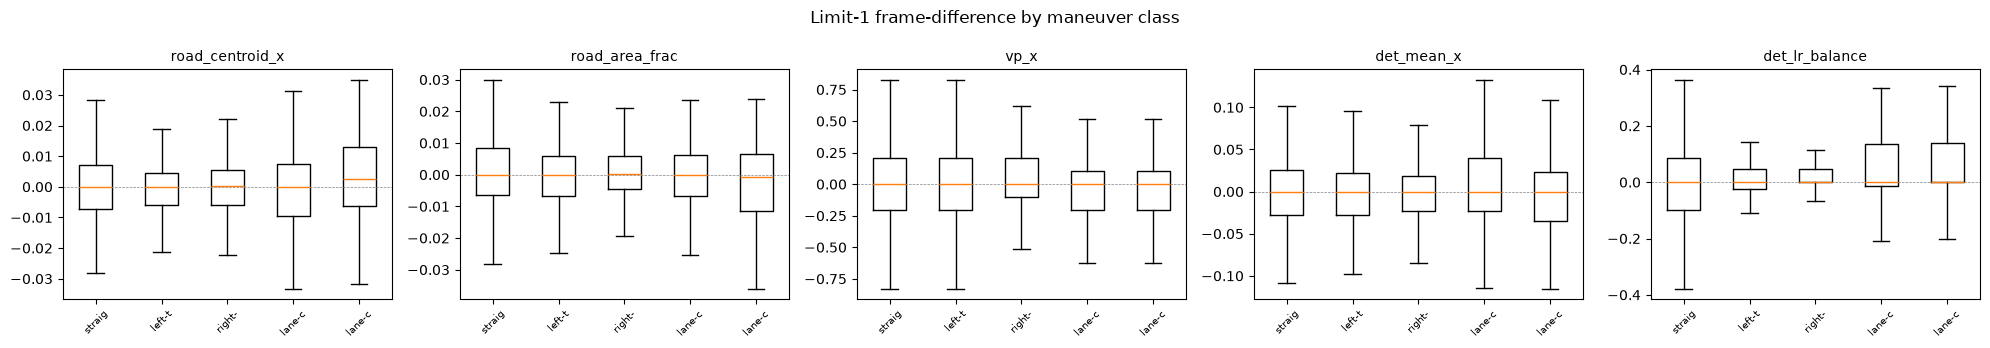

In [11]:
# distribution plots: each difference dim, by class
fig, axes = plt.subplots(1, len(QUANTITY_KEYS), figsize=(4 * len(QUANTITY_KEYS), 3.5))
for j, (ax, k) in enumerate(zip(axes, QUANTITY_KEYS)):
    data_by_class = [framediff[(labels == c) & valid_mask, j] for c in CLASSES]
    ax.boxplot(data_by_class, tick_labels=[c[:6] for c in CLASSES], showfliers=False)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_title(k, fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
plt.suptitle('Limit-1 frame-difference by maneuver class', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/framediff_by_class.png', dpi=120, bbox_inches='tight')
plt.show()